# Byzantine Classifier

In [1]:
%load_ext autoreload
import sys
import json
import time
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from datetime import timedelta
import pandas as pd
import seaborn as sns
from pathlib import Path
from fastnanoid import generate
from datetime import datetime

In [2]:
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [3]:
%autoreload 2
from lib.graph_factory import GraphFactory, add_graph_plot
from lib.proj_const_estimator import ProjConstEstimator
from lib.utils import fetch_dataset, get_alphas, rng, seed
from lib.classifier import ByzClassifier
from lib.system import SystemSimulator
from lib.config import BASE_CONF, LOGFILE, NUM_NODES

In [4]:
RUN_DIR = Path().resolve()
config = BASE_CONF
config['graph_type'] = 'erdos-renyi'
config['train']['b'] = 6
config['sys']['b'] = config['train']['b']

In [5]:
global_dataset = fetch_dataset('MNIST')
gf = GraphFactory(config['train']['num_nodes'], config['train']['b'], seed('graph'))
proj_const_estimator = ProjConstEstimator(config, global_dataset, rng('proj-const-estimator')) 
clf = ByzClassifier(config, global_dataset, gf, rng('byz-classifier'))
sys_sim = SystemSimulator(config, global_dataset, rng('ml-system-sim'), LOGFILE)

In [6]:
local_seed = seed('exp8','classifier-performance')
prelim_metrics = dict()

In [7]:
proj_const_estimator.configure(gf,config)
proj_const = proj_const_estimator.estimate()
prelim_metrics['proj_const'] = proj_const

In [8]:
ATKS = ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM']

In [9]:
train_sim_data = dict()
train_sim_seed = local_seed
for atk in ATKS:
    print(f'Building training set. Simulating {atk} (seed {train_sim_seed})')
    clf.init_simulation(config, proj_const)
    X, y, g = clf.simulate(atk, train_sim_seed, config['train']['beta_C'], config['train']['gamma_C'])
    train_sim_data[atk] = { 'X': X, 'y': y, 'g':g}

Building training set. Simulating label_flip (seed 3721819384)
Building training set. Simulating sign_flip (seed 3721819384)
Building training set. Simulating gaussian (seed 3721819384)
Building training set. Simulating ALIE (seed 3721819384)
Building training set. Simulating IPM (seed 3721819384)


In [10]:
val_sim_data = dict()
val_sim_seed = local_seed + 111
for atk in ATKS:
    print(f'Building validation set. Simulating {atk} (seed {val_sim_seed})')
    clf.init_simulation(config, proj_const)
    X, y, g = clf.simulate(atk, val_sim_seed, config['train']['beta_C'], config['train']['gamma_C'])
    val_sim_data[atk] = { 'X': X, 'y': y, 'g':g}

Building validation set. Simulating label_flip (seed 3721819495)
Building validation set. Simulating sign_flip (seed 3721819495)
Building validation set. Simulating gaussian (seed 3721819495)
Building validation set. Simulating ALIE (seed 3721819495)
Building validation set. Simulating IPM (seed 3721819495)


In [11]:
test_sim_data = dict()
test_sim_seed = local_seed + 777
for atk in ATKS:
    print(f'Building test set. Simulating {atk} (seed {test_sim_seed})')
    clf.init_simulation(config, proj_const)
    X, y, g = clf.simulate(atk, test_sim_seed, config['train']['beta_C'], config['train']['gamma_C'])
    test_sim_data[atk] = { 'X': X, 'y': y, 'g':g}

Building test set. Simulating label_flip (seed 3721820161)
Building test set. Simulating sign_flip (seed 3721820161)
Building test set. Simulating gaussian (seed 3721820161)
Building test set. Simulating ALIE (seed 3721820161)
Building test set. Simulating IPM (seed 3721820161)


In [12]:
# 5x5 comparison grid
rows = []
for train_atk, test_atk in product(ATKS, ATKS):
    print(f"train: {train_atk}, test: {test_atk}")
    
    Xtr = train_sim_data[train_atk]['X']
    ytr = train_sim_data[train_atk]['y']
    gtr = train_sim_data[train_atk]['g']

    Xva = val_sim_data[train_atk]['X']
    yva = val_sim_data[train_atk]['y']
    gva = val_sim_data[train_atk]['g']
    
    Xte = test_sim_data[test_atk]['X']
    yte = test_sim_data[test_atk]['y']
    gte = test_sim_data[test_atk]['g']
    
    clf.init_preproc()
    data_payload = dict(
        X_train=clf.feat_pre_proc.fit_transform(Xtr), y_train=ytr,
        groups_train=gtr, atk_train=list(train_atk),
        X_val=clf.feat_pre_proc.transform(Xva), y_val=yva,
        groups_val=gva, atk_val=list(train_atk),
        X_test=clf.feat_pre_proc.transform(Xte), y_test=yte,
        groups_test=gte, atk_test=list(test_atk),
        attack_names=list(train_atk),
        test_attack_names=list(test_atk))
    
    # Fitting model to training data
    C_best_est, C_pre_pipe = clf.train_and_eval(in_data=data_payload)

    # Calculating optimal operating point using validation set
    C_opt_pt = clf.calc_optimal_op_pt(in_data=data_payload)

    # Testing the classifier on test set
    C_metrics = clf.test(in_data=data_payload)

    run_results = dict()
    run_results.update(C_opt_pt)
    run_results.update(C_metrics)
    run_results['train_atk'] = train_atk
    run_results['test_atk'] = test_atk
    rows.append(run_results)

train: label_flip, test: label_flip
train: label_flip, test: sign_flip
train: label_flip, test: gaussian
train: label_flip, test: ALIE
train: label_flip, test: IPM
train: sign_flip, test: label_flip
train: sign_flip, test: sign_flip
train: sign_flip, test: gaussian
train: sign_flip, test: ALIE
train: sign_flip, test: IPM
train: gaussian, test: label_flip
train: gaussian, test: sign_flip
train: gaussian, test: gaussian
train: gaussian, test: ALIE
train: gaussian, test: IPM
train: ALIE, test: label_flip
train: ALIE, test: sign_flip
train: ALIE, test: gaussian
train: ALIE, test: ALIE
train: ALIE, test: IPM
train: IPM, test: label_flip
train: IPM, test: sign_flip
train: IPM, test: gaussian
train: IPM, test: ALIE
train: IPM, test: IPM


In [16]:
df1 = pd.DataFrame(rows)
df1.set_index(['train_atk', 'test_atk'], inplace=True)
df1.to_csv('tmp.csv')

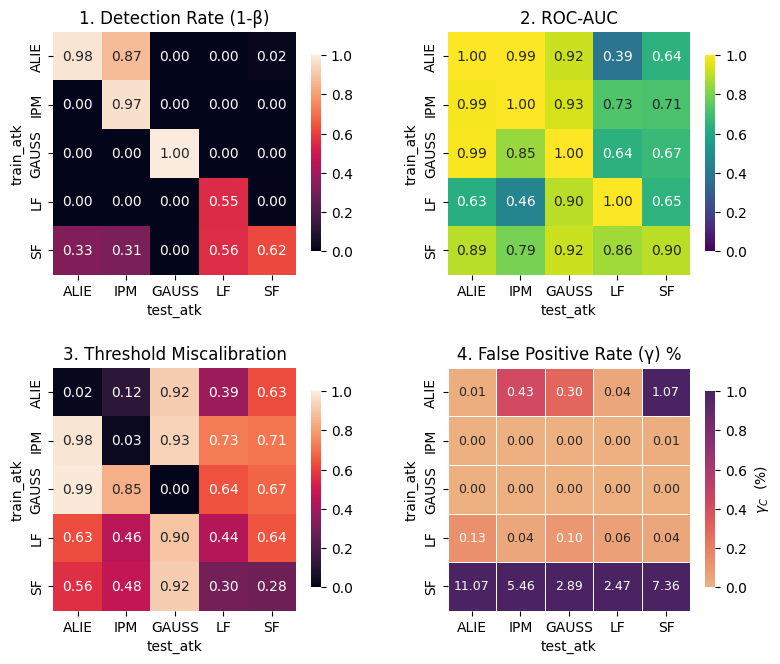

In [62]:
LABEL = {'label_flip': 'LF', 'sign_flip': 'SF', 'gaussian': 'GAUSS', 'ALIE': 'ALIE', 'IPM': 'IPM'}

fig, ax = plt.subplots(2,2,figsize=(9,8))

ax[0,0].set_title('1. Detection Rate (1-β)') 
sns.heatmap((1 - df1['beta_C']).unstack().rename(index=LABEL, columns=LABEL),
            annot=True, fmt='.2f', cmap='rocket', vmin=0, vmax=1,
            square=True, ax=ax[0,0], cbar_kws={'shrink': 0.7})

ax[0,1].set_title('2. ROC-AUC') 
sns.heatmap((df1['roc_auc']).unstack().rename(index=LABEL, columns=LABEL), 
            annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1, 
            square=True, cbar_kws={'shrink': 0.7}, ax=ax[0,1])

ax[1,0].set_title('3. Threshold Miscalibration') 
sns.heatmap((df1['roc_auc'] - (1 - df1['beta_C'])).unstack().rename(index=LABEL, columns=LABEL), 
            annot=True, cbar_kws={'shrink': 0.7}, fmt='.2f', cmap='rocket', vmin=0, vmax=1, square=True, ax=ax[1,0])

ax[1,1].set_title('4. False Positive Rate (γ) %') 
sns.heatmap((df1['gamma_C']*100).unstack().rename(index=LABEL, columns=LABEL), 
            annot=True, fmt='.2f', annot_kws={'size': 9}, 
            cbar_kws={'shrink': 0.7, 'label': '$\\gamma_C$  (%)'},
            linewidths=0.6, linecolor='white', square=True,
            cmap='flare', vmin=0, vmax=1, ax=ax[1,1])

fig.savefig("five_by_fiv_grids.png")
plt.subplots_adjust(wspace=0.3, hspace=0.2)
plt.show()

In [76]:
# LOO Analysis 
loo_seed = local_seed + 222
sys_sim.configure(gf, config, proj_const, C_pre_pipe, C_best_est, C_op_pt)
rows = []
for atk in ATKS:
    train_atks = list(set(ATKS).difference({atk}))
    test_atk = atk
    print(f"train: {train_atks}, test: {test_atk}")
    
    clf_sim_data = clf.run_simulations(config, proj_const, loo_seed, 
                                       training_attacks=train_atks, testing_attacks=[test_atk],
                                       beta_C=config['train']['beta_C'], gamma_C=config['train']['gamma_C'])
    C_best_est, C_pre_pipe = clf.train_and_eval()
    C_op_pt = clf.calc_optimal_op_pt()
    C_metrics = clf.test()

    run_results = dict()
    run_results.update(C_opt_pt)
    run_results.update(C_metrics)
    run_results['train_atks'] = train_atks
    run_results['test_atk'] = test_atk
    rows.append(run_results)

train: ['gaussian', 'sign_flip', 'IPM', 'ALIE'], test: label_flip
Simulating RDSGD @ (beta_C=0.1, gamma_C=0.12)
Building training set. Simulating ['gaussian', 'sign_flip', 'IPM', 'ALIE'] (seed 63270933325)
Building validation set. Simulating ['gaussian', 'sign_flip', 'IPM', 'ALIE'] (seed 40940015667)
  test set (sim 807634854533)
Building test set. Simulating ['label_flip'] (seed 807634854533)
train: ['gaussian', 'label_flip', 'IPM', 'ALIE'], test: sign_flip
Simulating RDSGD @ (beta_C=0.1, gamma_C=0.12)
Building training set. Simulating ['gaussian', 'label_flip', 'IPM', 'ALIE'] (seed 63270933325)
Building validation set. Simulating ['gaussian', 'label_flip', 'IPM', 'ALIE'] (seed 40940015667)
  test set (sim 807634854533)
Building test set. Simulating ['sign_flip'] (seed 807634854533)
train: ['label_flip', 'IPM', 'sign_flip', 'ALIE'], test: gaussian
Simulating RDSGD @ (beta_C=0.1, gamma_C=0.12)
Building training set. Simulating ['label_flip', 'IPM', 'sign_flip', 'ALIE'] (seed 6327093332

In [80]:
df2 = pd.DataFrame(rows)
df2.set_index('test_atk', inplace=True)

In [89]:
print(df2[['beta_C', 'gamma_C', 'roc_auc', 'avg_prec']])

              beta_C   gamma_C   roc_auc  avg_prec
test_atk                                          
label_flip  0.971579  0.016100  0.529898  0.302173
sign_flip   0.921333  0.002609  0.835627  0.719910
gaussian    1.000000  0.033587  0.777391  0.592739
ALIE        0.672143  0.015000  0.981344  0.913731
IPM         0.020455  0.044022  0.994499  0.985705
